In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.DataFrame(pd.read_csv("solar_system.csv"))

In [3]:
df.shape
# 20 rows, 11 columns

(20, 11)

In [4]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [5]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [6]:
df.columns

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')

In [7]:
for attribute in df["Attribute"]:
    print(attribute)

Mass (10^24kg)
Diameter (km)
Density (kg/m^3)
Gravity (m/s^2)
Escape Velocity (km/s)
Rotation Period (hours)
Length of Day (hours)
Distance from Sun (10^6 km)
Perihelion (10^6 km)
Aphelion (10^6 km)
Orbital Period (days)
Orbital Velocity (km/s)
Orbital Inclination (deg)
Orbital Eccentricity
Obliquity to Orbit (deg)
Mean Temperature (C)
Surface Pressure (bars)
Number of Moons
Ring System?
Global Magnetic Field?


In [8]:
df.iloc[10]

Attribute    Orbital Period (days)
Mercury                       88.0
Venus                        224.7
Earth                        365.2
Moon                          27.3
Mars                         687.0
Jupiter                       4331
Saturn                       10747
Uranus                       30589
Neptune                      59800
Pluto                        90560
Name: 10, dtype: object

In [9]:
df.iloc[8]

Attribute    Perihelion (10^6 km)
Mercury                      46.0
Venus                       107.5
Earth                       147.1
Moon                        0.363
Mars                        206.7
Jupiter                     740.6
Saturn                     1357.6
Uranus                     2732.7
Neptune                    4471.1
Pluto                      4436.8
Name: 8, dtype: object

In [10]:
df.iloc[9]

Attribute    Aphelion (10^6 km)
Mercury                    69.8
Venus                     108.9
Earth                     152.1
Moon                      0.406
Mars                      249.3
Jupiter                   816.4
Saturn                   1506.5
Uranus                   3001.4
Neptune                  4558.9
Pluto                    7375.9
Name: 9, dtype: object

In [11]:
# Perihelion is the point in the eliptical orbit of the Earth closest to the sun.
# Aphelion is the point in the eliptical orbit of the Earth farthest from the sun.
# The semi major axis is half the legth of the longest line connexting two points on an elipse.

In [12]:
perihelion = ()
for i in df.iloc[8, 1:11]:
    perihelion += (float(i),)

aphelion = ()
for i in df.iloc[9, 1:11]:
    aphelion += (float(i),)

semi_major_axis = []
for i, j in zip(perihelion, aphelion):
    semi_major_axis.append((i + j)/2)
semi_major_axis


[57.9, 108.2, 149.6, 0.3845, 228.0, 778.5, 1432.05, 2867.05, 4515.0, 5906.35]

In [13]:
semi_major_axis_df = pd.DataFrame({
    "Attribute": ["Semi Major Axis (10^6 km)"],
    "Mercury": [57.9],
    "Venus": [108.2],                  
"Earth": [149.6],
"Moon": [0.3845],
"Mars": [228.0],
"Jupiter": [778.5],
"Saturn": [1432.05],
"Uranus": [2867.05],
"Neptune": [4515.0],
"Pluto": [5906.35],
})
df = pd.concat([df, semi_major_axis_df], ignore_index=True)
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [14]:
df.shape
# 21 rows and 11 columns

(21, 11)

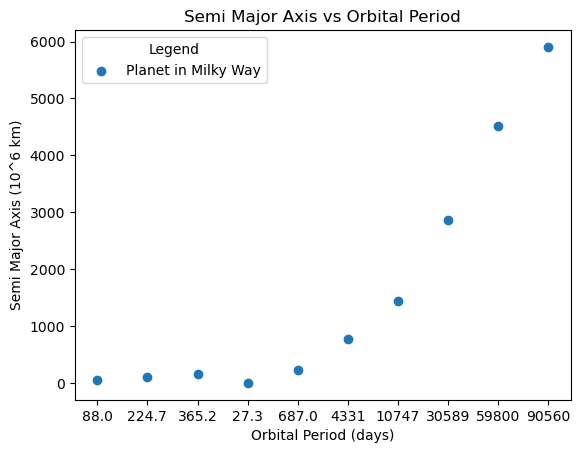

In [17]:
y = df.iloc[20, 1:11]
x = df.iloc[10, 1:11]

plt.scatter(x, y, label = "Planet in Milky Way")
plt.ylabel("Semi Major Axis (10^6 km)")
plt.xlabel("Orbital Period (days)")
plt.title("Semi Major Axis vs Orbital Period")
plt.legend(title = "Legend")

plt.show()

In [31]:
def keplers_third_law(a, m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, x, y)
a_fit, m_fit = popt
print(f"Fit: y = {m_fit:.2f} * {a_fit:.2f} ** 1.5)")

TypeError: unsupported operand type(s) for ** or pow(): 'str' and 'float'

In [32]:
residuals = y - keplers_third_law(a_fit, m_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
chi2_reduced

NameError: name 'a_fit' is not defined

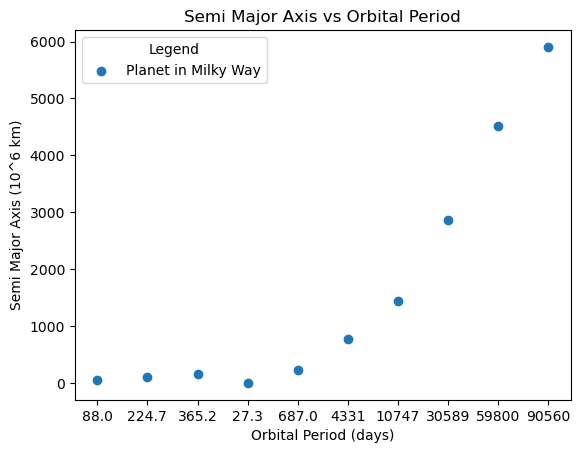

In [28]:
plt.scatter(x, y, label = "Planet in Milky Way")
plt.plot()
plt.ylabel("Semi Major Axis (10^6 km)")
plt.xlabel("Orbital Period (days)")
plt.title("Semi Major Axis vs Orbital Period")
plt.legend(title = "Legend")

plt.show()